# Group 51 — Model Comparison: 4 Architectures
### EfficientNetB0 vs ResNet50 vs MobileNetV2 vs DenseNet121 (all trained on `dataset_v2`)

Loads the `primary_best.pth` checkpoint from each of the 4 model folders
produced by `Group51_4Architecture_Training.ipynb`, evaluates all of them on
the same `dataset_v2/test` set, and produces a side-by-side comparison —
same pattern as `Group51_Model_Comparison.ipynb` (v1 vs v2), generalised
from 2 checkpoints of one architecture to 4 different architectures.


## Cell 1 — Check environment

In [1]:
import sys, os, platform
import torch

print(f'Python      : {sys.version}')
print(f'Platform    : {platform.platform()}')
print(f'PyTorch     : {torch.__version__}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')


Python      : 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
Platform    : macOS-26.5.1-arm64-arm-64bit
PyTorch     : 2.11.0
Using device: mps


## Cell 2 — Config (edit paths here)

In [2]:
import os
from pathlib import Path

# ── PATHS — update if your layout is different ─────────────────────────────
BASE = Path(os.path.expanduser('~/Downloads/Capstone_project/model_and_data_pipeline'))

ARCHITECTURES = ['efficientnet_b0', 'resnet50', 'mobilenet_v2', 'densenet121']

MODEL_PATHS = {arch: BASE / f'model_{arch}' / 'primary_best.pth' for arch in ARCHITECTURES}
JSON_PATHS  = {arch: BASE / f'model_{arch}' / 'class_indices.json' for arch in ARCHITECTURES}

TEST_DIR   = BASE / 'dataset_v2' / 'test'
OUTPUT_DIR = BASE / 'comparison_4arch'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── SETTINGS ──────────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXT     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('Paths configured.\n')
for arch in ARCHITECTURES:
    exists = MODEL_PATHS[arch].exists()
    flag = '✓' if exists else '✗ MISSING'
    print(f'  {arch:<16} -> {MODEL_PATHS[arch]}  [{flag}]')
print(f'\n  test dir -> {TEST_DIR}  — exists: {TEST_DIR.exists()}')

missing = [a for a in ARCHITECTURES if not MODEL_PATHS[a].exists()]
if missing:
    print(f'\n⚠  Missing checkpoints for: {missing}')
    print('   These will be skipped in the comparison below.')


Paths configured.

  efficientnet_b0  -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0/primary_best.pth  [✓]
  resnet50         -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_resnet50/primary_best.pth  [✓]
  mobilenet_v2     -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_mobilenet_v2/primary_best.pth  [✓]
  densenet121      -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_densenet121/primary_best.pth  [✓]

  test dir -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2/test  — exists: True


## Cell 3 — Load class indices & resolve test set

In [3]:
import json

# All 4 models were trained on the same dataset_v2 classes, so any one of
# their class_indices.json files should match — use the first one that exists.
json_path = None
for arch in ARCHITECTURES:
    if JSON_PATHS[arch].exists():
        json_path = JSON_PATHS[arch]
        break

if json_path is None:
    raise FileNotFoundError('No class_indices.json found in any model_<arch> folder.')

print(f'Using class indices: {json_path}')

with open(json_path) as f:
    CLASS_TO_IDX = json.load(f)

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
CLASS_NAMES  = [IDX_TO_CLASS[i] for i in range(len(IDX_TO_CLASS))]
NUM_CLASSES  = len(CLASS_NAMES)

print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')

# Sanity check: confirm every model's class_indices.json agrees
for arch in ARCHITECTURES:
    if JSON_PATHS[arch].exists():
        with open(JSON_PATHS[arch]) as f:
            other = json.load(f)
        if other != CLASS_TO_IDX:
            print(f'⚠  WARNING: {arch} class_indices.json differs from the reference — check for mismatched class ordering!')


Using class indices: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0/class_indices.json

Classes (8): ['e-waste', 'general_trash', 'glass', 'hazardous', 'metal', 'organic', 'paper', 'plastic']


## Cell 4 — Build test dataset & dataloader

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class WasteTestDataset(Dataset):
    def __init__(self, test_dir, class_to_idx, transform):
        self.samples = []
        self.transform = transform
        for cls, idx in class_to_idx.items():
            cls_dir = Path(test_dir) / cls
            if not cls_dir.exists():
                continue
            for f in cls_dir.iterdir():
                if f.suffix.lower() in VALID_EXT:
                    self.samples.append((str(f), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

test_dataset = WasteTestDataset(TEST_DIR, CLASS_TO_IDX, test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Test images loaded: {len(test_dataset)}')


Test images loaded: 9982


## Cell 5 — Build model (same head structure as training, per architecture)

In [5]:
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50,        ResNet50_Weights,
    mobilenet_v2,    MobileNet_V2_Weights,
    densenet121,     DenseNet121_Weights,
)

def make_head(in_features, num_classes, dropout_rate=0.4):
    return nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )

def build_model(arch_name, num_classes, dropout_rate=0.4):
    """Builds an UNTRAINED model with the right head — weights get loaded
    from the checkpoint right after, so pretrained=True here just gives us
    the correct architecture shape (loaded weights will overwrite it)."""
    if arch_name == 'efficientnet_b0':
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = model.classifier[1].in_features
        model.classifier = make_head(in_f, num_classes, dropout_rate)
    elif arch_name == 'resnet50':
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        in_f = model.fc.in_features
        model.fc = make_head(in_f, num_classes, dropout_rate)
    elif arch_name == 'mobilenet_v2':
        model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        in_f = model.classifier[1].in_features
        model.classifier = make_head(in_f, num_classes, dropout_rate)
    elif arch_name == 'densenet121':
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_f = model.classifier.in_features
        model.classifier = make_head(in_f, num_classes, dropout_rate)
    else:
        raise ValueError(f'Unknown architecture: {arch_name}')
    return model

print('Model builder ready for:', ARCHITECTURES)


Model builder ready for: ['efficientnet_b0', 'resnet50', 'mobilenet_v2', 'densenet121']


## Cell 6 — Evaluate all 4 models

In [6]:
import time
import numpy as np
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluate_checkpoint(arch_name, model_path):
    if not Path(model_path).exists():
        print(f'⚠  {arch_name} not found at {model_path} — skipping.')
        return None

    print(f'Loading {arch_name} …')
    model = build_model(arch_name, NUM_CLASSES).to(DEVICE)

    state = torch.load(model_path, map_location=DEVICE)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    model.load_state_dict(state)
    model.eval()

    all_preds, all_labels = [], []
    t0 = time.time()
    for images, labels in tqdm(test_loader, desc=f'  {arch_name}'):
        images = images.to(DEVICE)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    elapsed = time.time() - t0
    ms_per_image = (elapsed / len(test_dataset)) * 1000

    labels_arr = np.array(all_labels)
    preds_arr  = np.array(all_preds)
    acc = accuracy_score(labels_arr, preds_arr)

    total_params = sum(p.numel() for p in model.parameters())
    size_mb = os.path.getsize(model_path) / (1024 * 1024)

    print(f'  ✓ {arch_name} accuracy: {acc*100:.2f}%  |  '
          f'{ms_per_image:.2f} ms/img  |  {size_mb:.1f} MB\n')

    return {
        'labels': labels_arr,
        'preds': preds_arr,
        'acc': acc,
        'params': total_params,
        'size_mb': size_mb,
        'ms_per_image': ms_per_image,
    }

results = {}
for arch in ARCHITECTURES:
    r = evaluate_checkpoint(arch, MODEL_PATHS[arch])
    if r:
        results[arch] = r

print(f'\nEvaluated {len(results)}/{len(ARCHITECTURES)} models successfully.')


Loading efficientnet_b0 …


  efficientnet_b0:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ efficientnet_b0 accuracy: 79.89%  |  3.91 ms/img  |  16.8 MB

Loading resnet50 …


  resnet50:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ resnet50 accuracy: 85.46%  |  8.69 ms/img  |  92.0 MB

Loading mobilenet_v2 …


  mobilenet_v2:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ mobilenet_v2 accuracy: 80.71%  |  3.76 ms/img  |  10.0 MB

Loading densenet121 …


  densenet121:   0%|          | 0/312 [00:00<?, ?it/s]

  ✓ densenet121 accuracy: 76.88%  |  12.35 ms/img  |  28.1 MB


Evaluated 4/4 models successfully.


## Cell 7 — Classification report (per architecture)

In [7]:
from sklearn.metrics import classification_report

for arch, r in results.items():
    print('=' * 65)
    print(f'  {arch}')
    print('=' * 65)
    report = classification_report(r['labels'], r['preds'], target_names=CLASS_NAMES, digits=4)
    print(report)
    with open(OUTPUT_DIR / f'{arch}_classification_report.txt', 'w') as f:
        f.write(f"Accuracy: {r['acc']:.4f}\n\n")
        f.write(report)
    print()


  efficientnet_b0
               precision    recall  f1-score   support

      e-waste     0.7822    0.9473    0.8569       474
general_trash     0.8746    0.8966    0.8855      1354
        glass     0.6390    0.9063    0.7495       619
    hazardous     0.5238    0.9795    0.6826       146
        metal     0.5209    0.9235    0.6661       392
      organic     0.9289    0.7828    0.8496      3490
        paper     0.7132    0.8650    0.7818      1133
      plastic     0.8252    0.6462    0.7248      2374

     accuracy                         0.7989      9982
    macro avg     0.7260    0.8684    0.7746      9982
 weighted avg     0.8255    0.7989    0.8016      9982


  resnet50
               precision    recall  f1-score   support

      e-waste     0.8297    0.9662    0.8928       474
general_trash     0.9155    0.9439    0.9295      1354
        glass     0.7371    0.9241    0.8201       619
    hazardous     0.8372    0.9863    0.9057       146
        metal     0.7041    0.9

## Cell 8 — Confusion matrices (all 4 side by side)

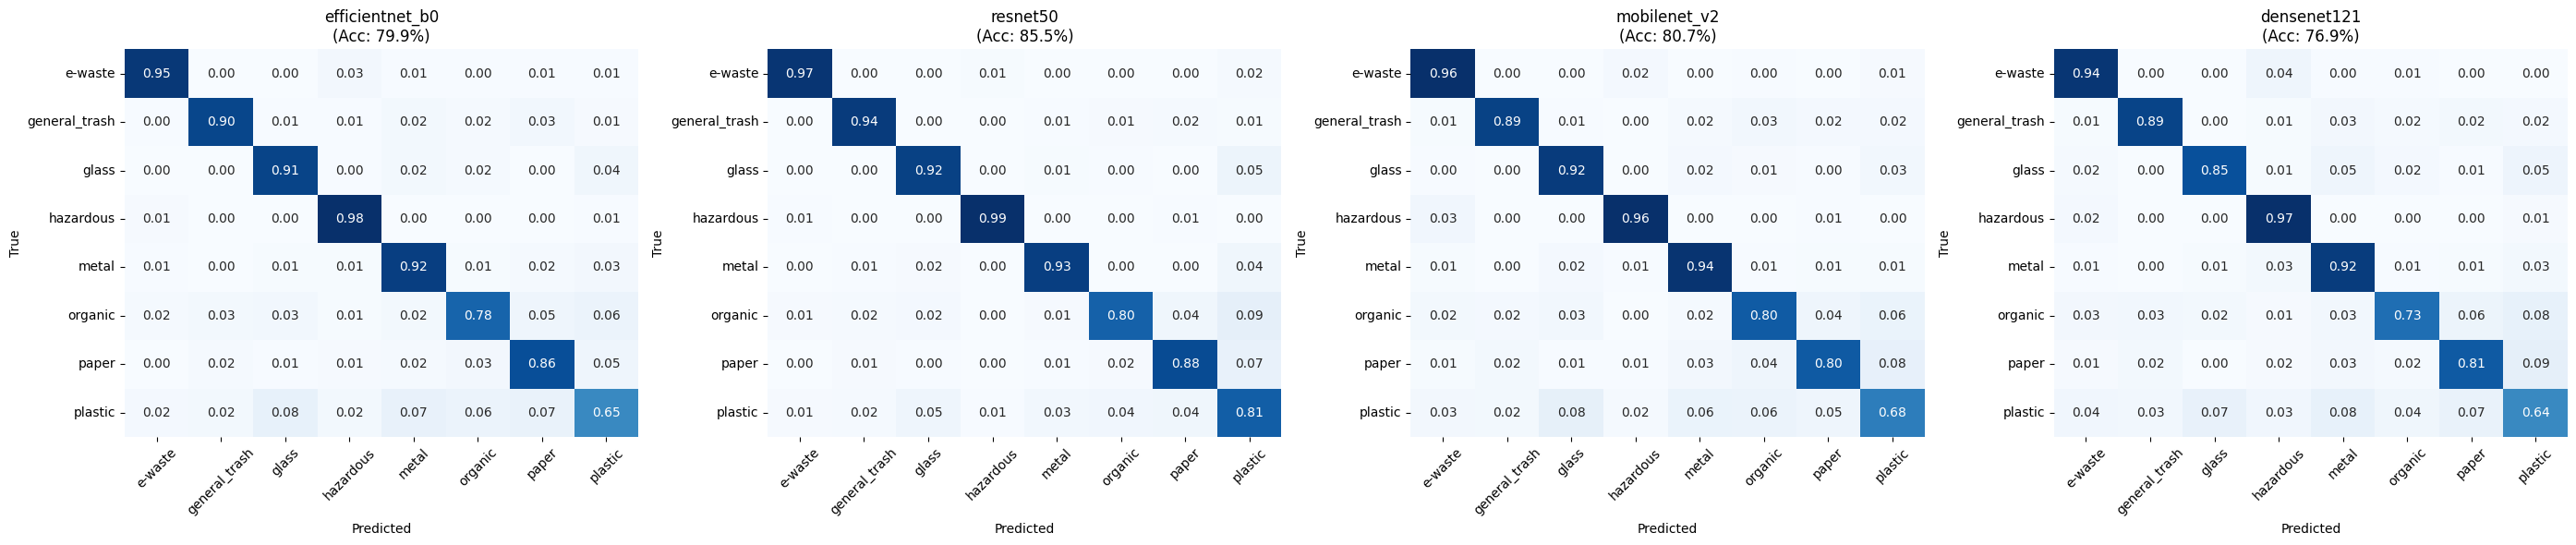

Saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison_4arch/all_confusion_matrices.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
if n == 1:
    axes = [axes]

for ax, (arch, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
               xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(f'{arch}\n(Acc: {r["acc"]*100:.1f}%)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUTPUT_DIR / "all_confusion_matrices.png"}')


## Cell 9 — Per-class F1 comparison

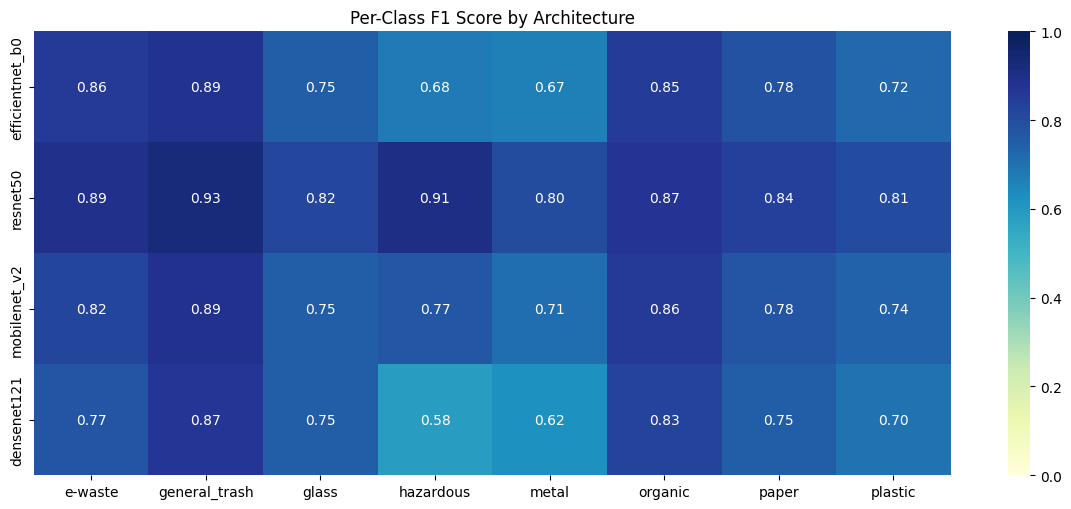


Per-class F1 table:
                 e-waste  general_trash  glass  hazardous  metal  organic  paper  plastic
efficientnet_b0    0.857          0.885  0.749      0.683  0.666    0.850  0.782    0.725
resnet50           0.893          0.929  0.820      0.906  0.801    0.871  0.837    0.807
mobilenet_v2       0.821          0.889  0.750      0.771  0.709    0.857  0.777    0.740
densenet121        0.774          0.869  0.747      0.583  0.624    0.826  0.747    0.699


In [9]:
from sklearn.metrics import f1_score
import pandas as pd

per_class_f1 = {}
for arch, r in results.items():
    f1s = f1_score(r['labels'], r['preds'], average=None)
    per_class_f1[arch] = {CLASS_NAMES[i]: f1s[i] for i in range(NUM_CLASSES)}

per_class_df = pd.DataFrame(per_class_f1).T  # rows = arch, cols = class

fig, ax = plt.subplots(figsize=(12, 4 + 0.3 * len(results)))
sns.heatmap(per_class_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=ax)
ax.set_title('Per-Class F1 Score by Architecture')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class F1 table:')
print(per_class_df.round(3).to_string())
per_class_df.round(4).to_csv(OUTPUT_DIR / 'per_class_f1.csv')


## Cell 10 — Overall accuracy, size/speed comparison & summary

MODEL COMPARISON SUMMARY

          Model  Accuracy  F1 (weighted)  F1 (macro)  Params (M)  Checkpoint (MB)  Inference (ms/img)
       resnet50    0.8546         0.8555      0.8580       24.04             92.0                8.69
   mobilenet_v2    0.8071         0.8090      0.7894        2.55             10.0                3.76
efficientnet_b0    0.7989         0.8016      0.7746        4.34             16.8                3.91
    densenet121    0.7688         0.7740      0.7336        7.22             28.1               12.35


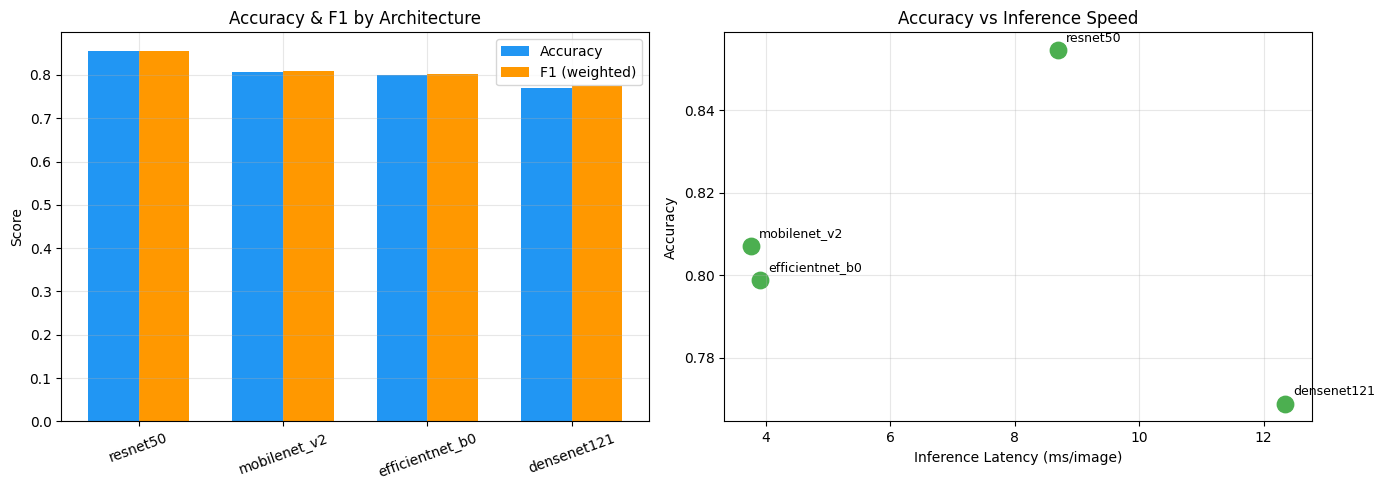


🏆  Best overall: resnet50  (Accuracy: 85.46%, F1: 0.8555)

All outputs saved to: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison_4arch
  - accuracy_f1_comparison.png
  - all_confusion_matrices.png
  - architecture_comparison.png
  - comparison_summary.csv
  - comparison_table.csv
  - densenet121_classification_report.txt
  - efficientnet_b0_classification_report.txt
  - full_summary.json
  - mobilenet_v2_classification_report.txt
  - per_class_f1.csv
  - per_class_f1_heatmap.png
  - resnet50_classification_report.txt


In [10]:
names = list(results.keys())

summary_rows = []
for arch in names:
    r = results[arch]
    weighted_f1 = f1_score(r['labels'], r['preds'], average='weighted')
    macro_f1    = f1_score(r['labels'], r['preds'], average='macro')
    summary_rows.append({
        'Model': arch,
        'Accuracy': round(r['acc'], 4),
        'F1 (weighted)': round(weighted_f1, 4),
        'F1 (macro)': round(macro_f1, 4),
        'Params (M)': round(r['params'] / 1e6, 2),
        'Checkpoint (MB)': round(r['size_mb'], 1),
        'Inference (ms/img)': round(r['ms_per_image'], 2),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('MODEL COMPARISON SUMMARY\n')
print(summary_df.to_string(index=False))
summary_df.to_csv(OUTPUT_DIR / 'comparison_summary.csv', index=False)

# ── Bar chart: accuracy & F1 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(summary_df))
w = 0.35
axes[0].bar(x - w/2, summary_df['Accuracy'], w, label='Accuracy', color='#2196F3')
axes[0].bar(x + w/2, summary_df['F1 (weighted)'], w, label='F1 (weighted)', color='#FF9800')
axes[0].set_xticks(x); axes[0].set_xticklabels(summary_df['Model'], rotation=20)
axes[0].set_ylabel('Score'); axes[0].set_title('Accuracy & F1 by Architecture')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary_df['Inference (ms/img)'], summary_df['Accuracy'], s=140, color='#4CAF50')
for _, row in summary_df.iterrows():
    axes[1].annotate(row['Model'], (row['Inference (ms/img)'], row['Accuracy']),
                     textcoords='offset points', xytext=(6, 6), fontsize=9)
axes[1].set_xlabel('Inference Latency (ms/image)'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Inference Speed'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = summary_df.iloc[0]
print(f"\n🏆  Best overall: {best['Model']}  (Accuracy: {best['Accuracy']*100:.2f}%, "
      f"F1: {best['F1 (weighted)']:.4f})")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  - {f.name}')
